# Comprehensive Risk Assessment

This notebook combines frequency and severity analysis to conduct comprehensive risk assessment:
- Risk score calculation (Risk = Frequency × Severity)
- Multi-hazard risk mapping
- Vulnerability assessment
- High-risk area identification
- Risk prioritization for intervention

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from config import PROCESSED_DATA_DIR, FIGURES_DIR, HAZARD_TYPES
from src.risk_metrics import (
    calculate_risk_score,
    calculate_vulnerability_index,
    classify_risk_level
)
from src.visualization import (
    plot_risk_matrix,
    plot_risk_heatmap,
    create_risk_map
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Enhanced Data

In [2]:
# Load data with severity metrics from notebook 03
data_file = PROCESSED_DATA_DIR / 'disaster_events_with_severity.csv'

if data_file.exists():
    df = pd.read_csv(data_file)
    print(f"Loaded {len(df)} records with severity metrics")
    print(f"\nColumns: {df.columns.tolist()}")
    print(f"\nTime period: {df['year'].min()} - {df['year'].max()}")
else:
    print("⚠️  Enhanced data not found. Please run notebook 03 first.")
    df = None

Loaded 30 records with severity metrics

Columns: ['serial', 'glide', 'year', 'month', 'day', 'eventname', 'level1', 'level2', 'level3', 'latitude', 'longitude', 'hazardtype', 'deaths', 'injured', 'missing', 'affected', 'displaced', 'housesdestroyed', 'housesdamaged', 'educationcenters', 'healthcenters', 'localvalue', 'usdvalue', 'durationdays', 'eventdescription', 'date', 'season', 'total_affected', 'total_deaths', 'total_houses_affected', 'has_economic_data', 'has_coordinates', 'severity_index', 'severity_class']

Time period: 2010 - 2023


## 2. Calculate Frequency Metrics by Location and Hazard

In [3]:
if df is not None:
    years_covered = df['year'].max() - df['year'].min() + 1
    
    # Calculate frequency by location and hazard type
    location_hazard_freq = df.groupby(['level2', 'hazardtype']).agg({
        'year': 'count',
        'severity_index': 'mean'
    }).reset_index()
    
    location_hazard_freq.columns = ['location', 'hazard', 'event_count', 'mean_severity']
    location_hazard_freq['annual_frequency'] = location_hazard_freq['event_count'] / years_covered
    
    print("Frequency Metrics Calculated:")
    print("="*60)
    print(f"Total location-hazard combinations: {len(location_hazard_freq)}")
    print(f"\nSample:")
    display(location_hazard_freq.head(10))

Frequency Metrics Calculated:
Total location-hazard combinations: 29

Sample:


,location,hazard,event_count,mean_severity,annual_frequency
0,Addis Ababa,FLOOD,1,19.918957,0.071429
1,Afar,EARTHQUAKE,1,15.146280,0.071429
2,Banadir,DROUGHT,1,21.596494,0.071429
3,Bay,DROUGHT,1,26.524476,0.071429
4,Central,FLOOD,1,16.617524,0.071429
5,Coast,HEAVY RAIN,1,14.528524,0.071429
6,Dar es Salaam,STORM,1,14.556078,0.071429
7,Eastern,DROUGHT,1,20.493422,0.071429
8,Eastern,FLOOD,1,18.262079,0.071429
9,Kagera,FLOOD,1,18.887675,0.071429


## 3. Calculate Risk Scores

In [4]:
if df is not None:
    # Calculate risk score: Risk = Frequency × Severity
    location_hazard_freq['risk_score'] = (
        location_hazard_freq['annual_frequency'] * 
        location_hazard_freq['mean_severity']
    )
    
    # Normalize risk score to 0-100 scale
    max_risk = location_hazard_freq['risk_score'].max()
    location_hazard_freq['risk_score_normalized'] = (
        (location_hazard_freq['risk_score'] / max_risk) * 100
    )
    
    # Classify risk level
    location_hazard_freq['risk_level'] = location_hazard_freq['risk_score_normalized'].apply(
        classify_risk_level
    )
    
    print("Risk Scores Calculated:")
    print("="*60)
    print(f"\nRisk Score Statistics:")
    print(f"  Mean: {location_hazard_freq['risk_score_normalized'].mean():.2f}")
    print(f"  Median: {location_hazard_freq['risk_score_normalized'].median():.2f}")
    print(f"  Max: {location_hazard_freq['risk_score_normalized'].max():.2f}")
    
    print("\nRisk Level Distribution:")
    risk_dist = location_hazard_freq['risk_level'].value_counts()
    for level in ['Low', 'Medium', 'High', 'Very High']:
        count = risk_dist.get(level, 0)
        pct = (count / len(location_hazard_freq)) * 100
        print(f"  {level}: {count} ({pct:.1f}%)")

Risk Scores Calculated:

Risk Score Statistics:
  Mean: 55.79
  Median: 55.22
  Max: 100.00

Risk Level Distribution:
  Low: 0 (0.0%)
  Medium: 2 (6.9%)
  High: 19 (65.5%)
  Very High: 7 (24.1%)


## 4. High-Risk Areas Identification

🚨 TOP 20 HIGHEST RISK COMBINATIONS:


,location,hazard,event_count,annual_frequency,mean_severity,risk_score_normalized,risk_level
15,Nairobi,FLOOD,2,0.142857,17.102896,100.000000,Critical
11,Lower Shabelle,DROUGHT,1,0.071429,27.158081,79.396147,Very High
3,Bay,DROUGHT,1,0.071429,26.524476,77.543813,Very High
24,Somali,DROUGHT,1,0.071429,23.337245,68.226002,Very High
19,Nyanza,FLOOD,1,0.071429,21.778166,63.668064,Very High
2,Banadir,DROUGHT,1,0.071429,21.596494,63.136950,Very High
27,Western,FLOOD,1,0.071429,21.312635,62.307094,Very High
17,North Eastern,DROUGHT,1,0.071429,20.869998,61.013052,Very High
7,Eastern,DROUGHT,1,0.071429,20.493422,59.912139,High
12,Morogoro,FLOOD,1,0.071429,20.455565,59.801466,High


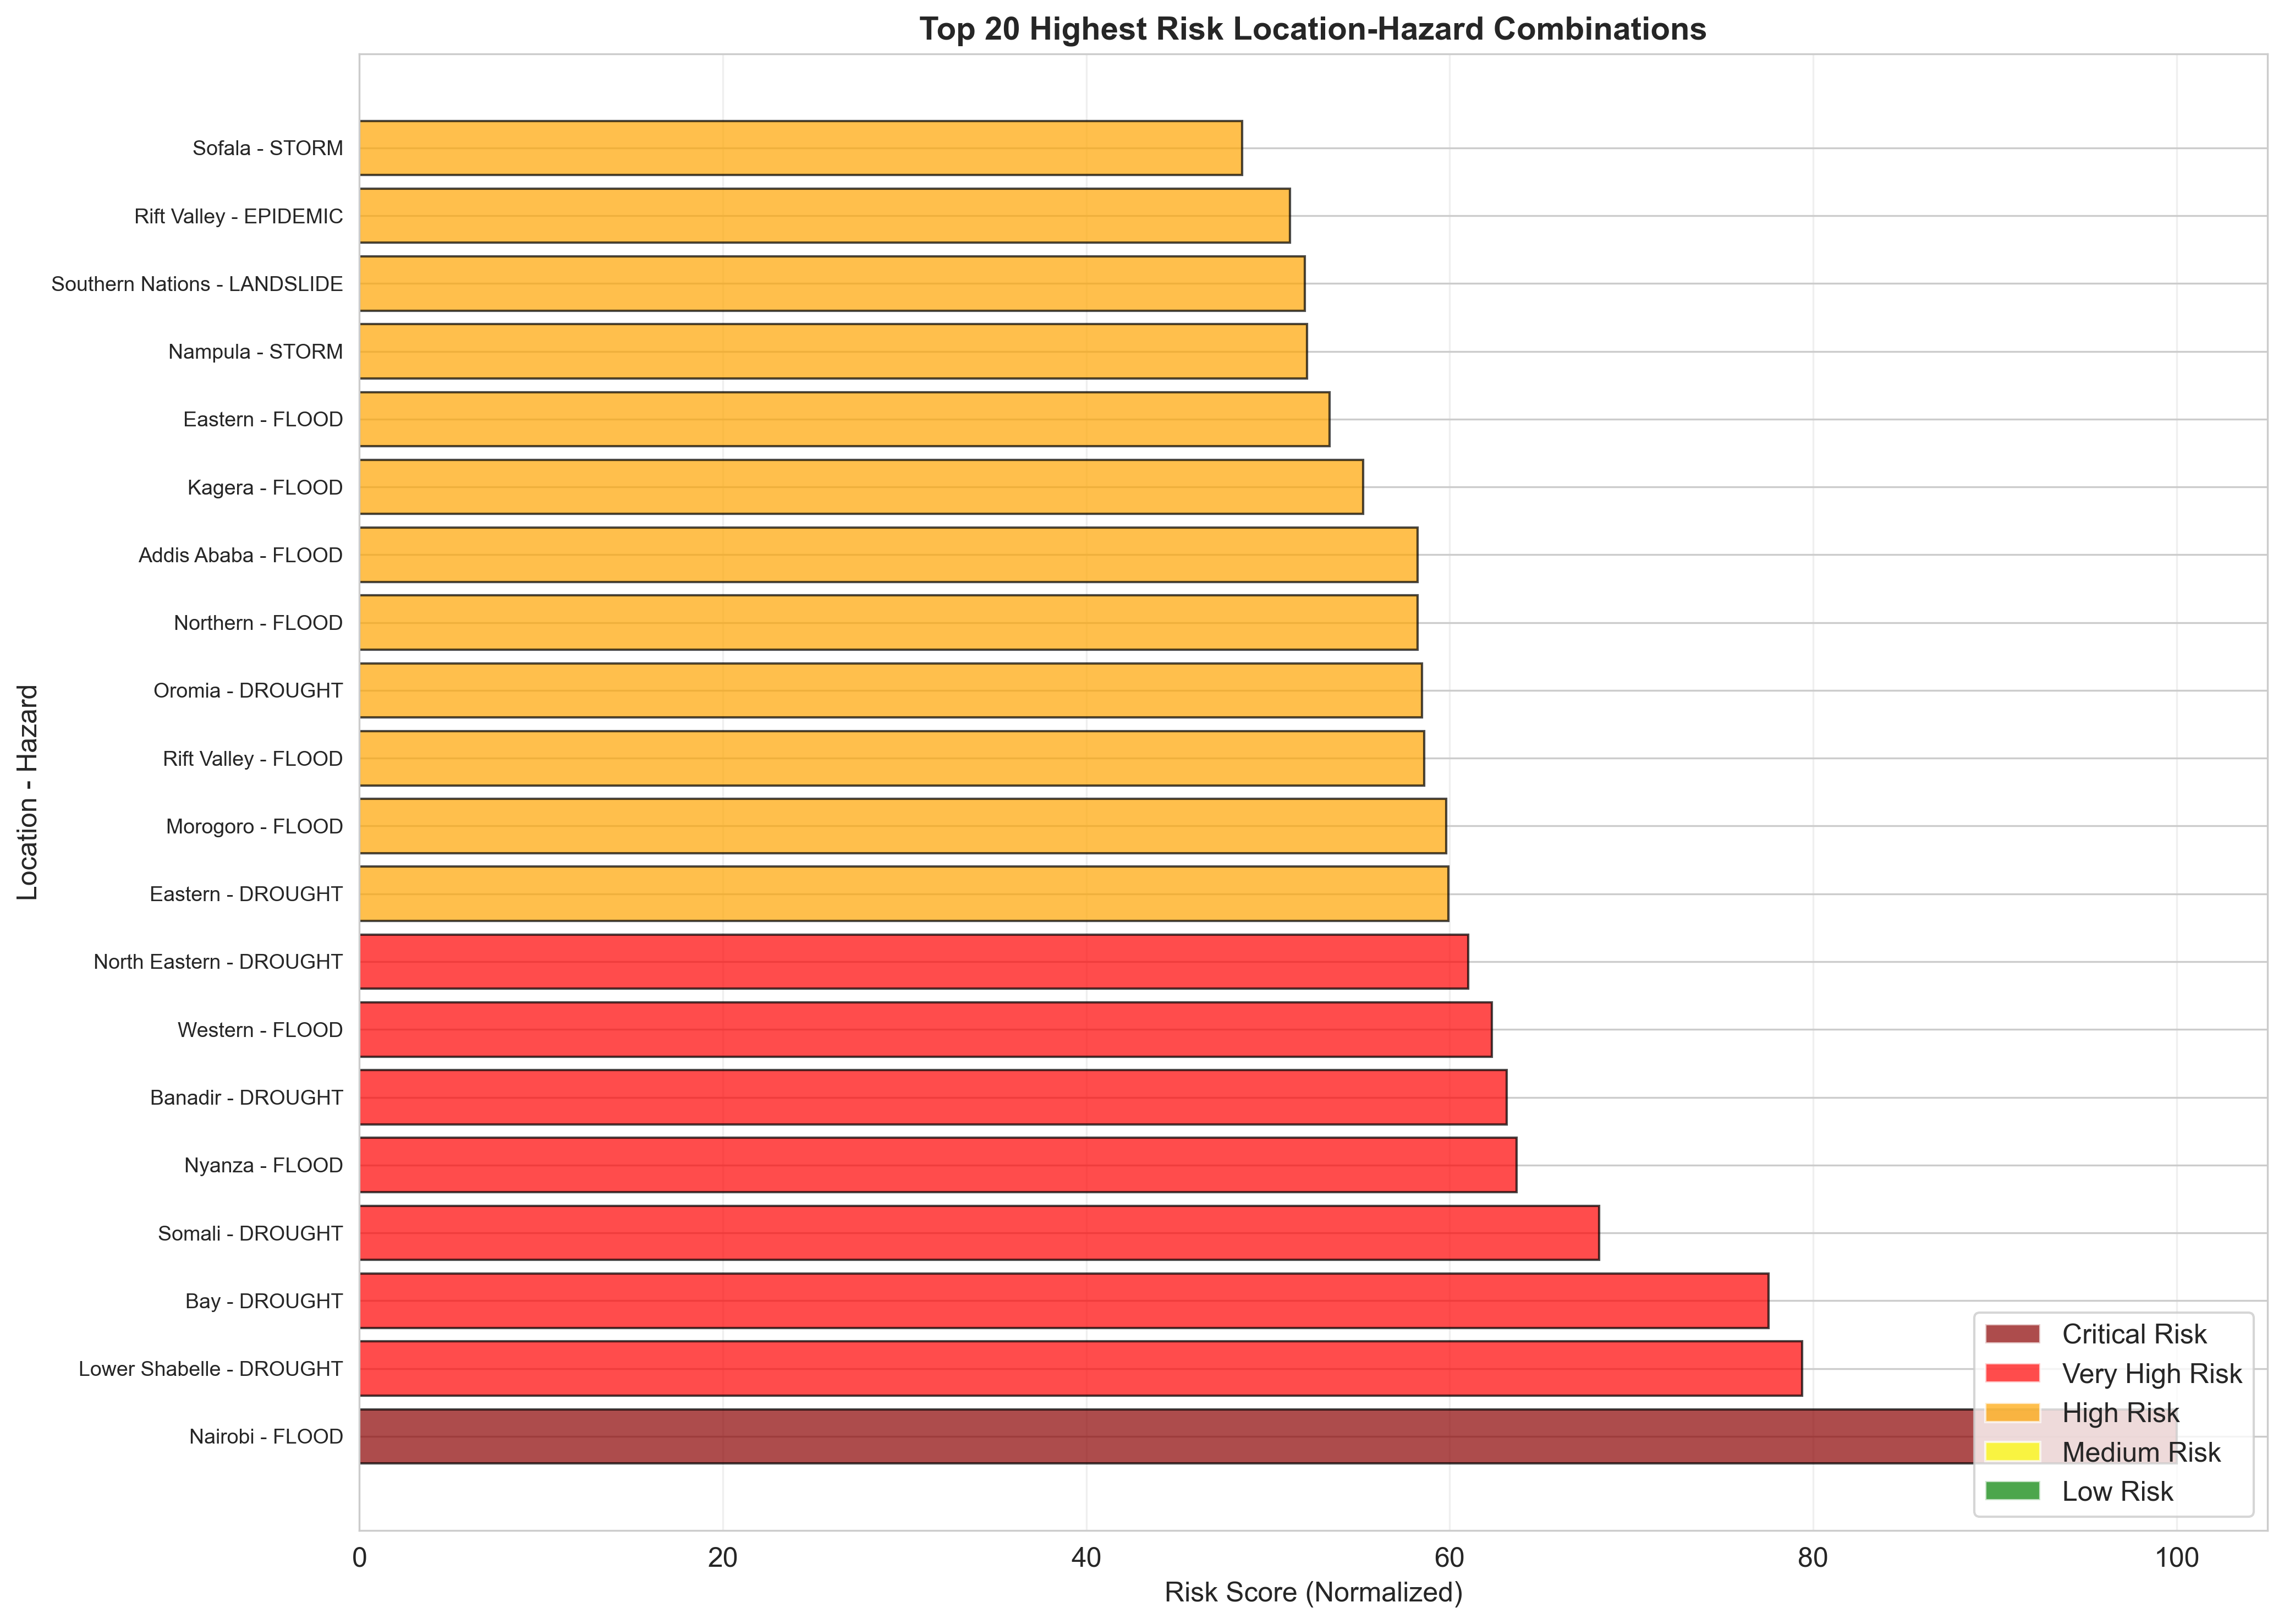

In [5]:
if df is not None:
    # Top 20 highest risk location-hazard combinations
    top_risks = location_hazard_freq.nlargest(20, 'risk_score_normalized')[[
        'location', 'hazard', 'event_count', 'annual_frequency', 
        'mean_severity', 'risk_score_normalized', 'risk_level'
    ]]
    
    print("🚨 TOP 20 HIGHEST RISK COMBINATIONS:")
    print("="*80)
    display(top_risks)
    
    # Visualize top risks
    fig, ax = plt.subplots(figsize=(14, 10))
    
    top_risks_plot = top_risks.copy()
    top_risks_plot['label'] = top_risks_plot['location'] + ' - ' + top_risks_plot['hazard']
    
    colors = top_risks_plot['risk_level'].map({
        'Low': 'green',
        'Medium': 'yellow',
        'High': 'orange',
        'Very High': 'red',
        'Critical': 'darkred'
    })
    
    ax.barh(range(len(top_risks_plot)), top_risks_plot['risk_score_normalized'], 
            color=colors, alpha=0.7, edgecolor='black')
    ax.set_yticks(range(len(top_risks_plot)))
    ax.set_yticklabels(top_risks_plot['label'], fontsize=9)
    ax.set_xlabel('Risk Score (Normalized)', fontsize=12)
    ax.set_ylabel('Location - Hazard', fontsize=12)
    ax.set_title('Top 20 Highest Risk Location-Hazard Combinations', 
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='darkred', alpha=0.7, label='Critical Risk'),
        Patch(facecolor='red', alpha=0.7, label='Very High Risk'),
        Patch(facecolor='orange', alpha=0.7, label='High Risk'),
        Patch(facecolor='yellow', alpha=0.7, label='Medium Risk'),
        Patch(facecolor='green', alpha=0.7, label='Low Risk')
    ]
    ax.legend(handles=legend_elements, loc='lower right')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '04_top_risks.png', dpi=300, bbox_inches='tight')
    plt.show()

## 5. Risk Matrix (Frequency vs Severity)

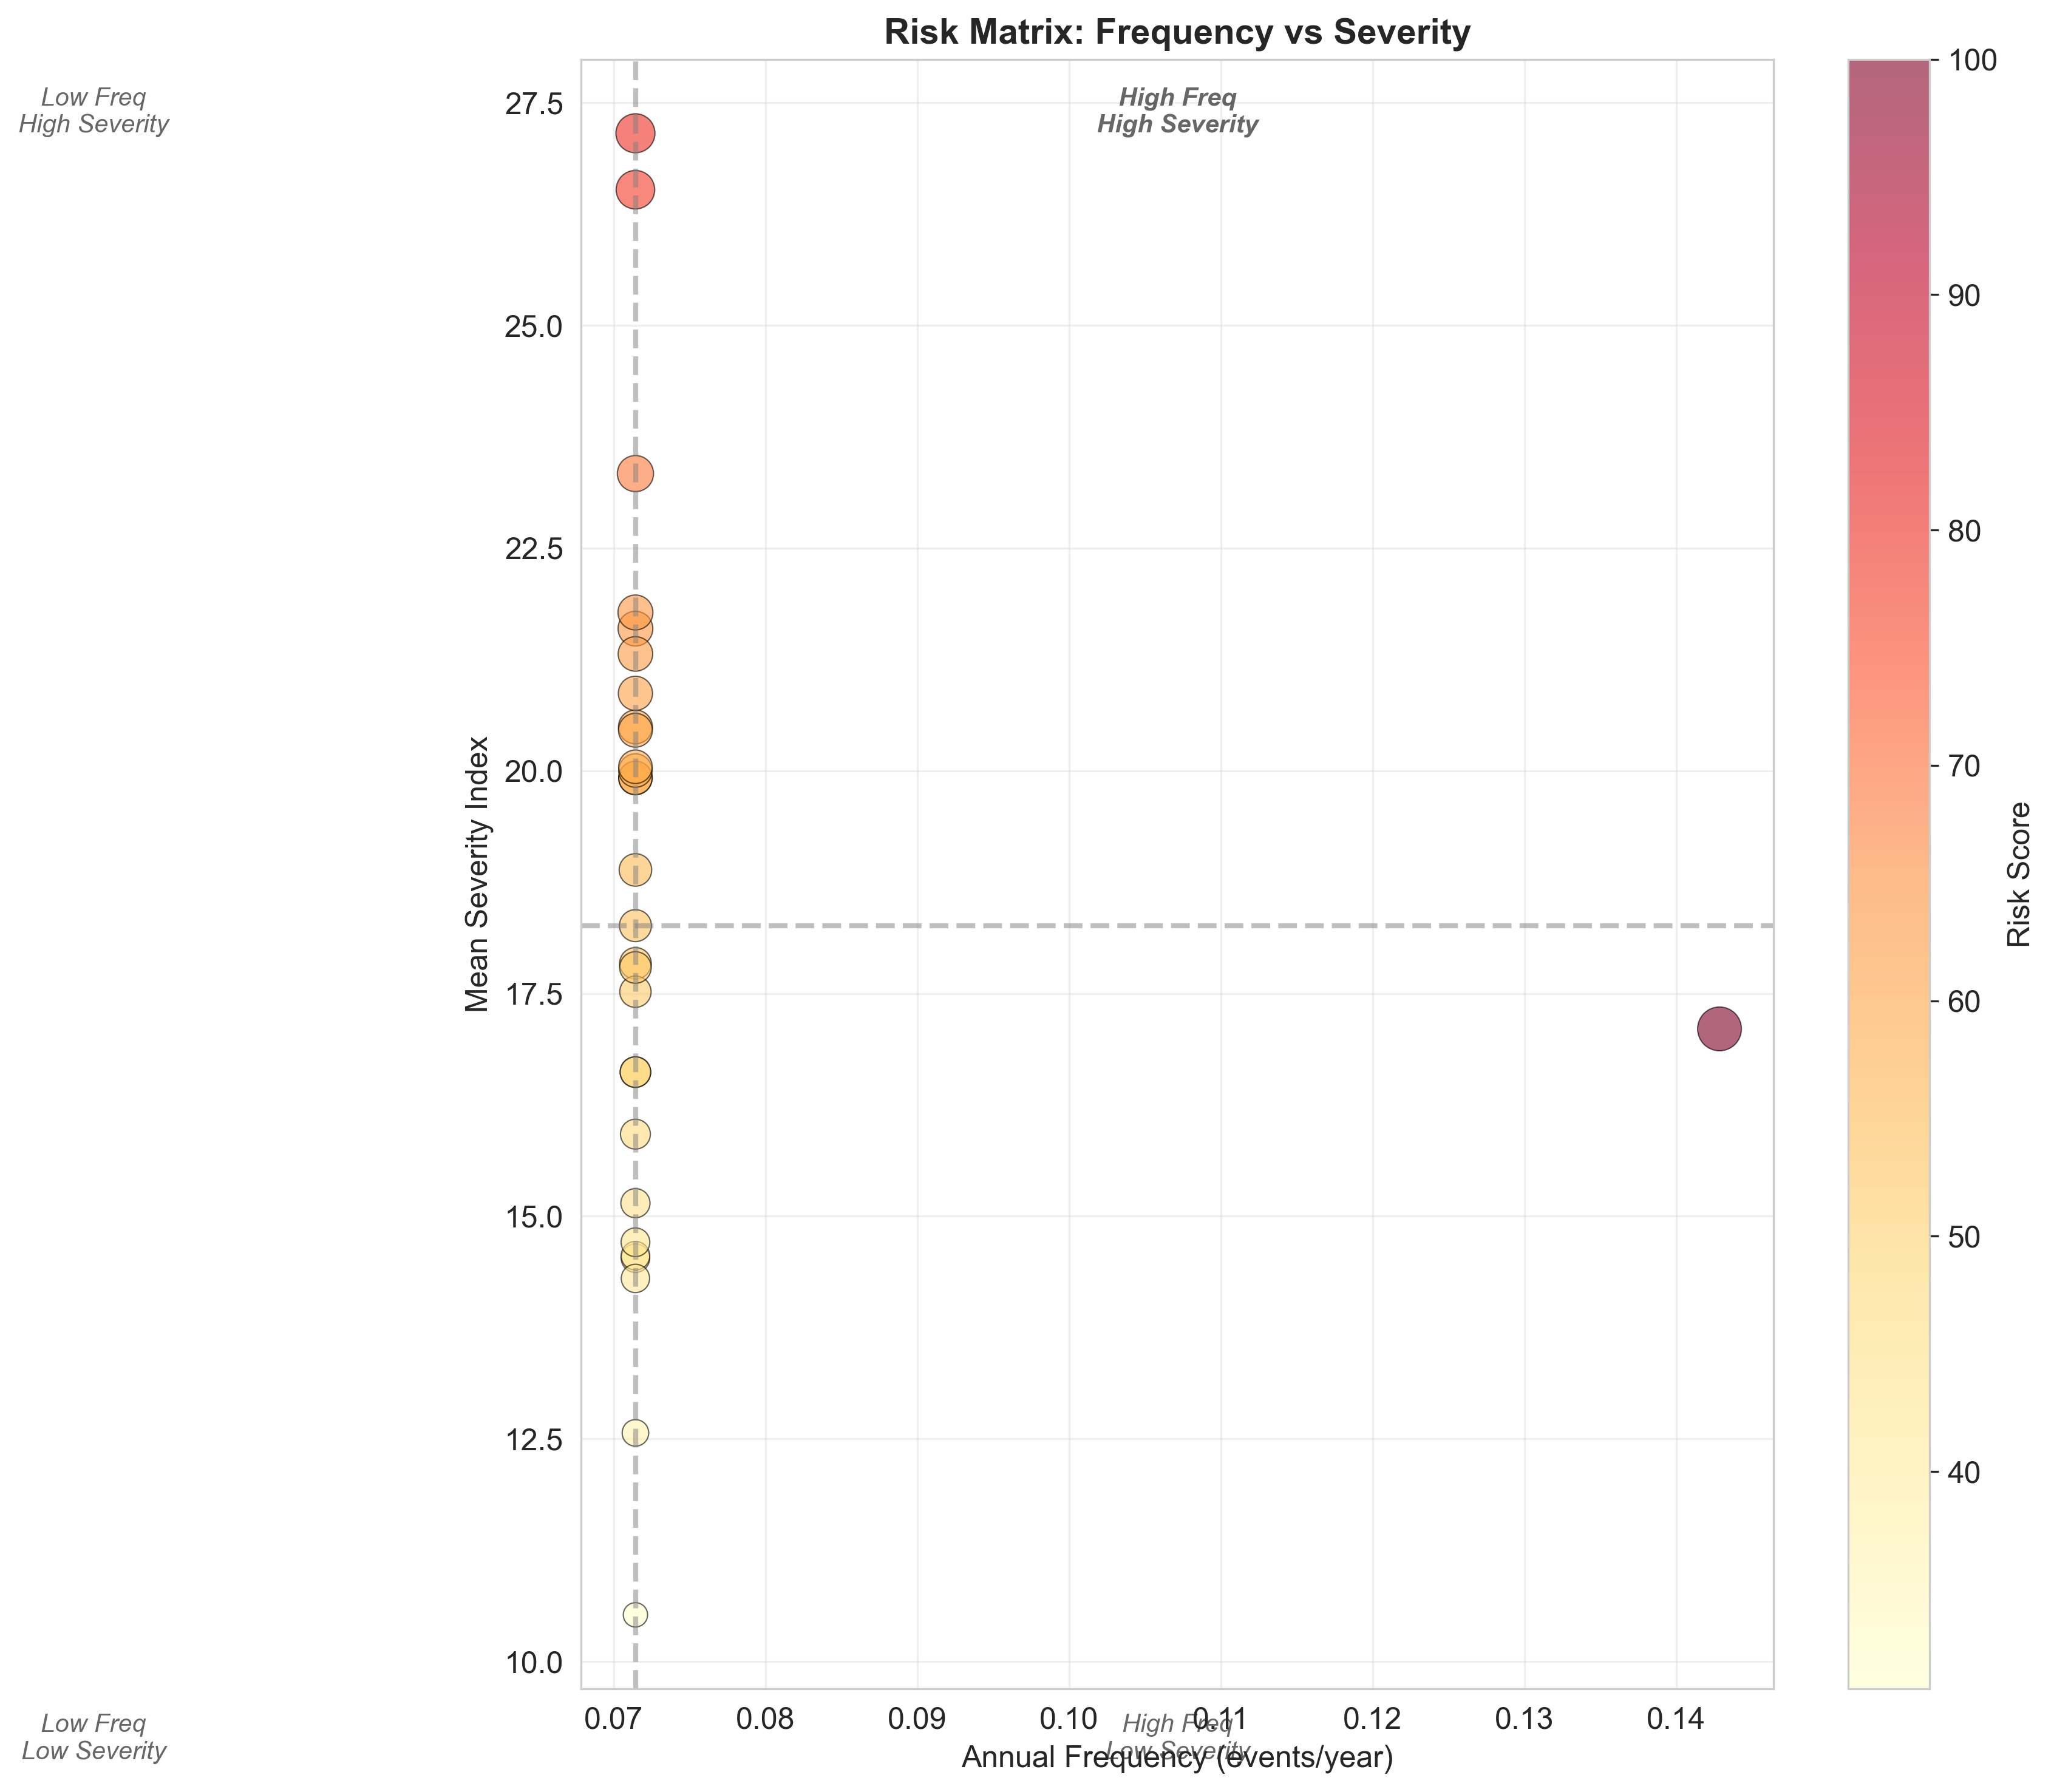

In [6]:
if df is not None:
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Create scatter plot
    scatter = ax.scatter(
        location_hazard_freq['annual_frequency'],
        location_hazard_freq['mean_severity'],
        s=location_hazard_freq['risk_score_normalized'] * 3,
        c=location_hazard_freq['risk_score_normalized'],
        cmap='YlOrRd',
        alpha=0.6,
        edgecolors='black',
        linewidth=0.5
    )
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Risk Score', fontsize=12)
    
    # Add quadrant lines
    median_freq = location_hazard_freq['annual_frequency'].median()
    median_sev = location_hazard_freq['mean_severity'].median()
    
    ax.axvline(median_freq, color='gray', linestyle='--', alpha=0.5, linewidth=2)
    ax.axhline(median_sev, color='gray', linestyle='--', alpha=0.5, linewidth=2)
    
    # Add quadrant labels
    ax.text(median_freq * 0.5, median_sev * 1.5, 'Low Freq\nHigh Severity', 
            ha='center', va='center', fontsize=10, alpha=0.7, style='italic')
    ax.text(median_freq * 1.5, median_sev * 1.5, 'High Freq\nHigh Severity', 
            ha='center', va='center', fontsize=10, alpha=0.7, style='italic', weight='bold')
    ax.text(median_freq * 0.5, median_sev * 0.5, 'Low Freq\nLow Severity', 
            ha='center', va='center', fontsize=10, alpha=0.7, style='italic')
    ax.text(median_freq * 1.5, median_sev * 0.5, 'High Freq\nLow Severity', 
            ha='center', va='center', fontsize=10, alpha=0.7, style='italic')
    
    ax.set_xlabel('Annual Frequency (events/year)', fontsize=12)
    ax.set_ylabel('Mean Severity Index', fontsize=12)
    ax.set_title('Risk Matrix: Frequency vs Severity', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '04_risk_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

## 6. Multi-Hazard Risk by Location

Multi-Hazard Risk Assessment by Location:

Top 15 Highest Risk Locations:


,location,total_risk,hazard_count,total_events,avg_severity
13,Nairobi,141.810015,2,3,15.702171
7,Eastern,113.300988,2,2,19.377750
19,Rift Valley,109.822749,2,2,18.782871
24,Western,108.851679,2,2,18.616790
10,Lower Shabelle,79.396147,1,1,27.158081
3,Bay,77.543813,1,1,26.524476
21,Somali,68.226002,1,1,23.337245
17,Nyanza,63.668064,1,1,21.778166
2,Banadir,63.136950,1,1,21.596494
15,North Eastern,61.013052,1,1,20.869998


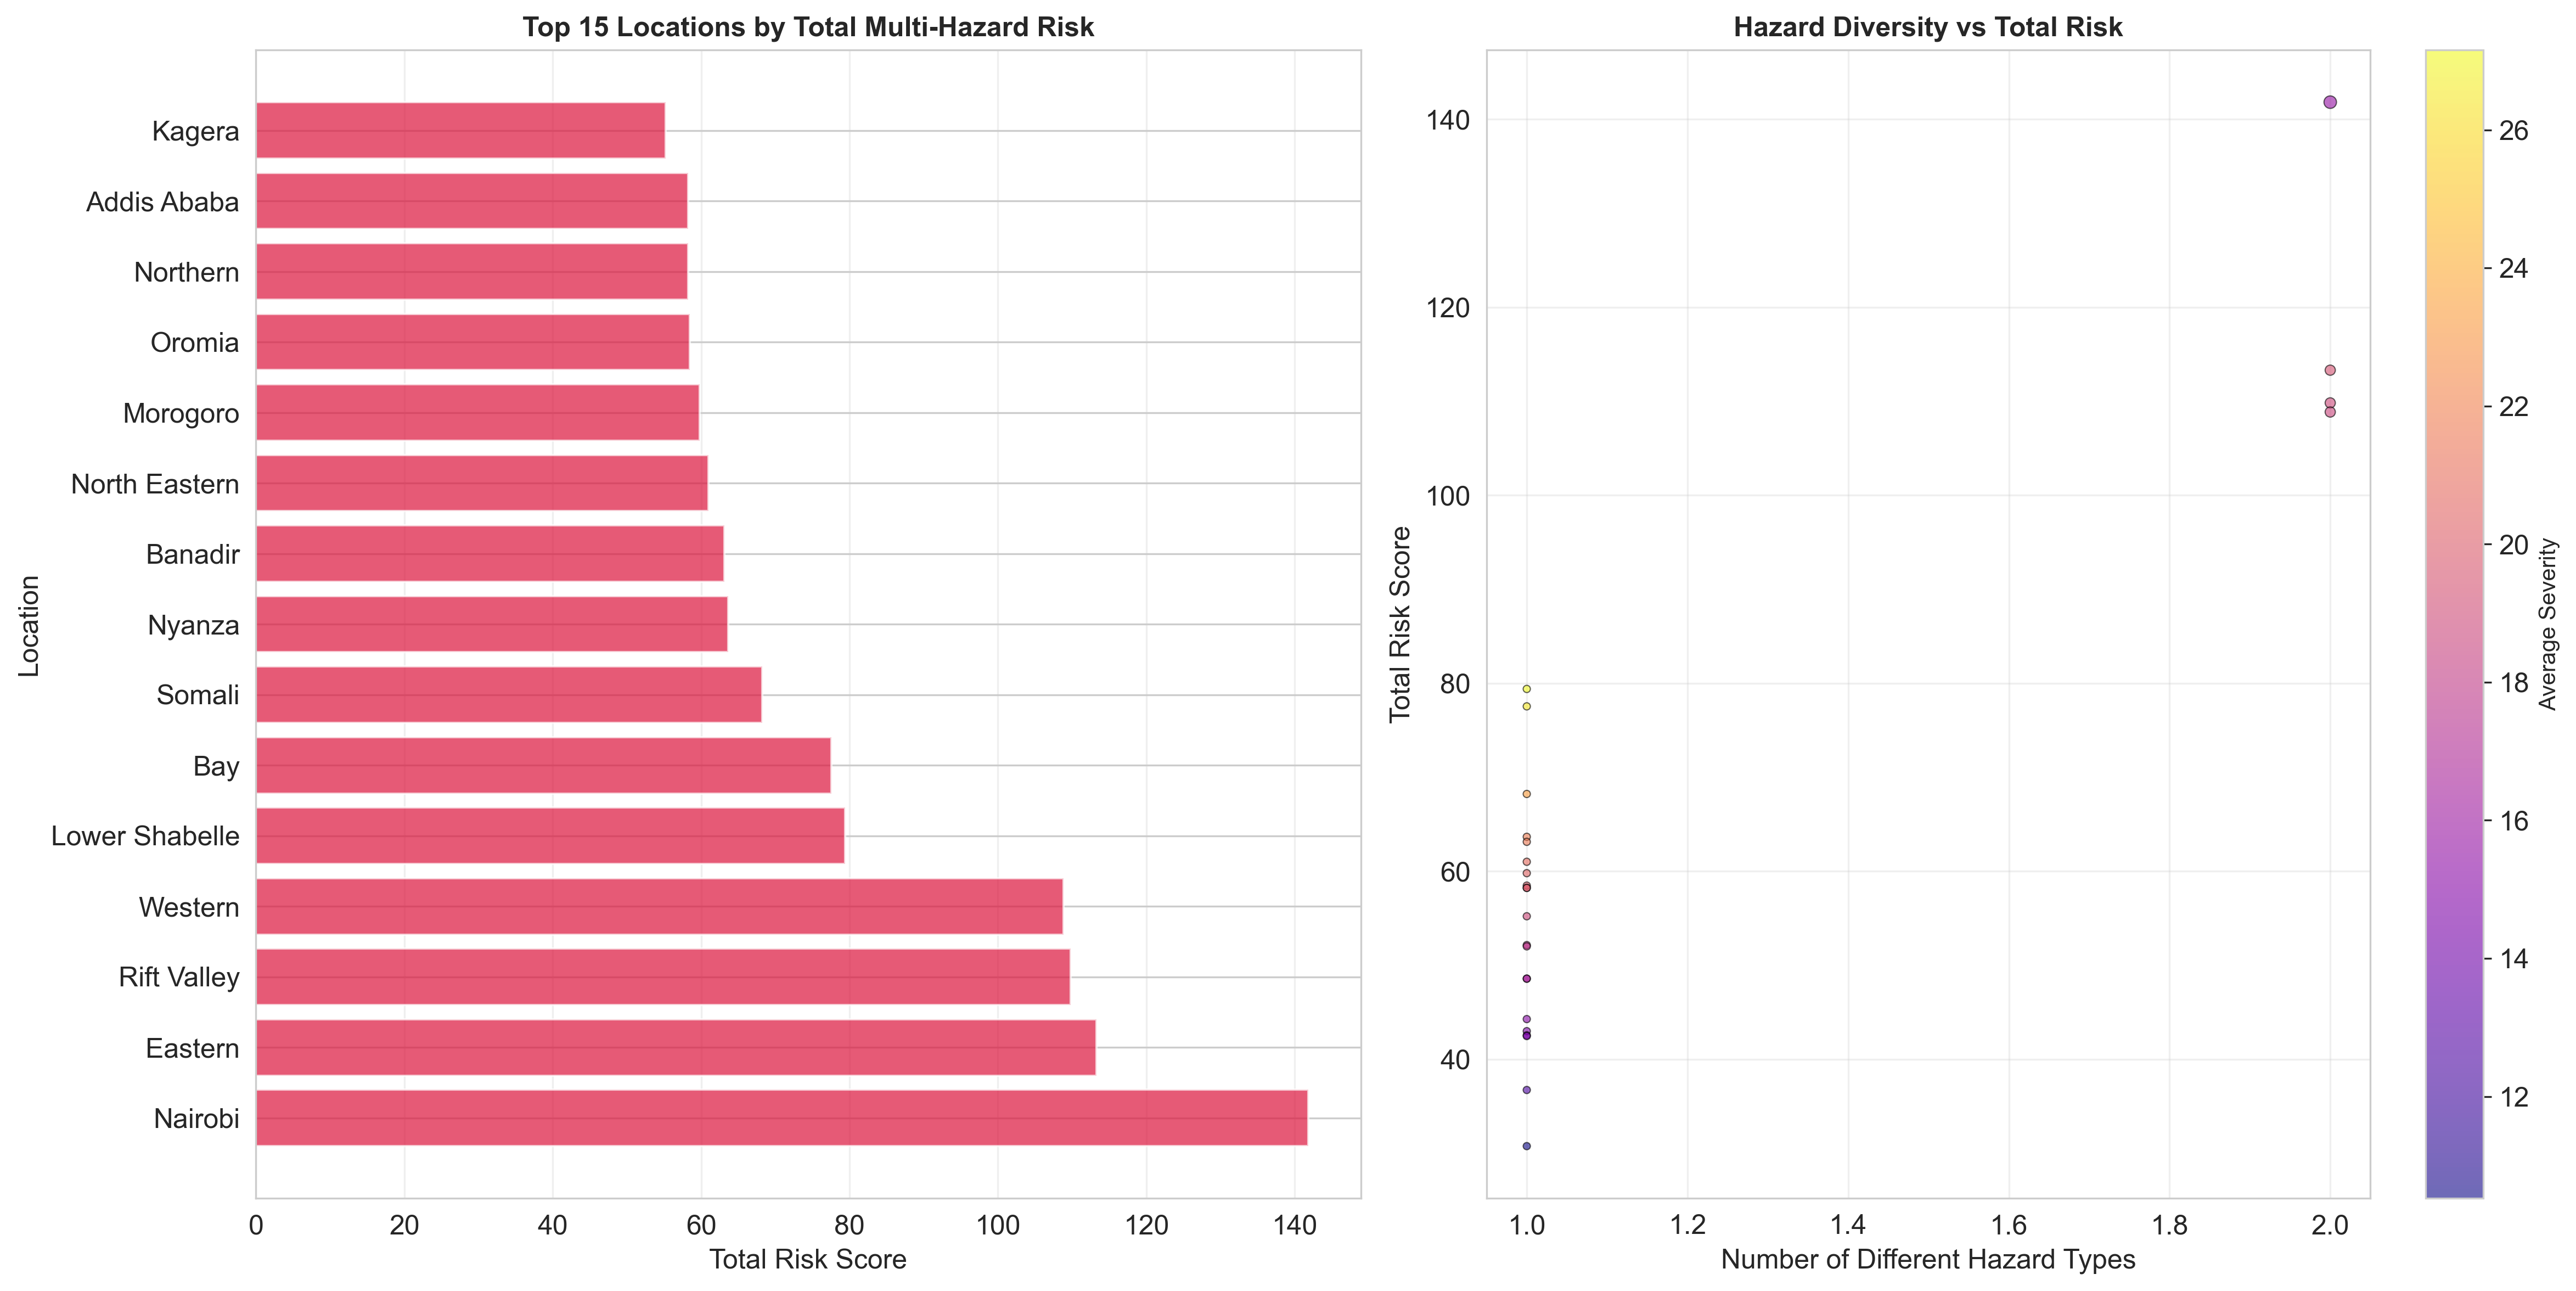

In [7]:
if df is not None:
    # Aggregate risk by location across all hazards
    location_risk = location_hazard_freq.groupby('location').agg({
        'risk_score_normalized': 'sum',  # Total risk across all hazards
        'hazard': 'count',  # Number of different hazards
        'event_count': 'sum',  # Total events
        'mean_severity': 'mean'  # Average severity
    }).reset_index()
    
    location_risk.columns = ['location', 'total_risk', 'hazard_count', 'total_events', 'avg_severity']
    location_risk = location_risk.sort_values('total_risk', ascending=False)
    
    print("Multi-Hazard Risk Assessment by Location:")
    print("="*60)
    print("\nTop 15 Highest Risk Locations:")
    display(location_risk.head(15))
    
    # Visualize
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Total risk by location
    top_15 = location_risk.head(15)
    ax1.barh(range(len(top_15)), top_15['total_risk'], color='crimson', alpha=0.7)
    ax1.set_yticks(range(len(top_15)))
    ax1.set_yticklabels(top_15['location'])
    ax1.set_xlabel('Total Risk Score', fontsize=12)
    ax1.set_ylabel('Location', fontsize=12)
    ax1.set_title('Top 15 Locations by Total Multi-Hazard Risk', 
                  fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='x')
    
    # Hazard diversity vs total risk
    scatter = ax2.scatter(
        location_risk['hazard_count'],
        location_risk['total_risk'],
        s=location_risk['total_events'] * 10,
        c=location_risk['avg_severity'],
        cmap='plasma',
        alpha=0.6,
        edgecolors='black',
        linewidth=0.5
    )
    ax2.set_xlabel('Number of Different Hazard Types', fontsize=12)
    ax2.set_ylabel('Total Risk Score', fontsize=12)
    ax2.set_title('Hazard Diversity vs Total Risk', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    cbar = plt.colorbar(scatter, ax=ax2)
    cbar.set_label('Average Severity', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '04_location_multi_hazard_risk.png', dpi=300, bbox_inches='tight')
    plt.show()

## 7. Risk by Hazard Type

Risk Assessment by Hazard Type:


,hazard,total_risk,mean_risk,max_risk,affected_locations,total_events
4,FLOOD,618.039227,61.803923,100.000000,10,11
0,DROUGHT,467.707608,66.815373,79.396147,7,7
7,STORM,223.023857,44.604771,52.151237,5,5
6,LANDSLIDE,98.559680,49.279840,52.015095,2,2
3,FIRE,72.577809,36.288905,41.810015,2,2
2,EPIDEMIC,51.219583,51.219583,51.219583,1,1
1,EARTHQUAKE,44.279869,44.279869,44.279869,1,1
5,HEAVY RAIN,42.473870,42.473870,42.473870,1,1


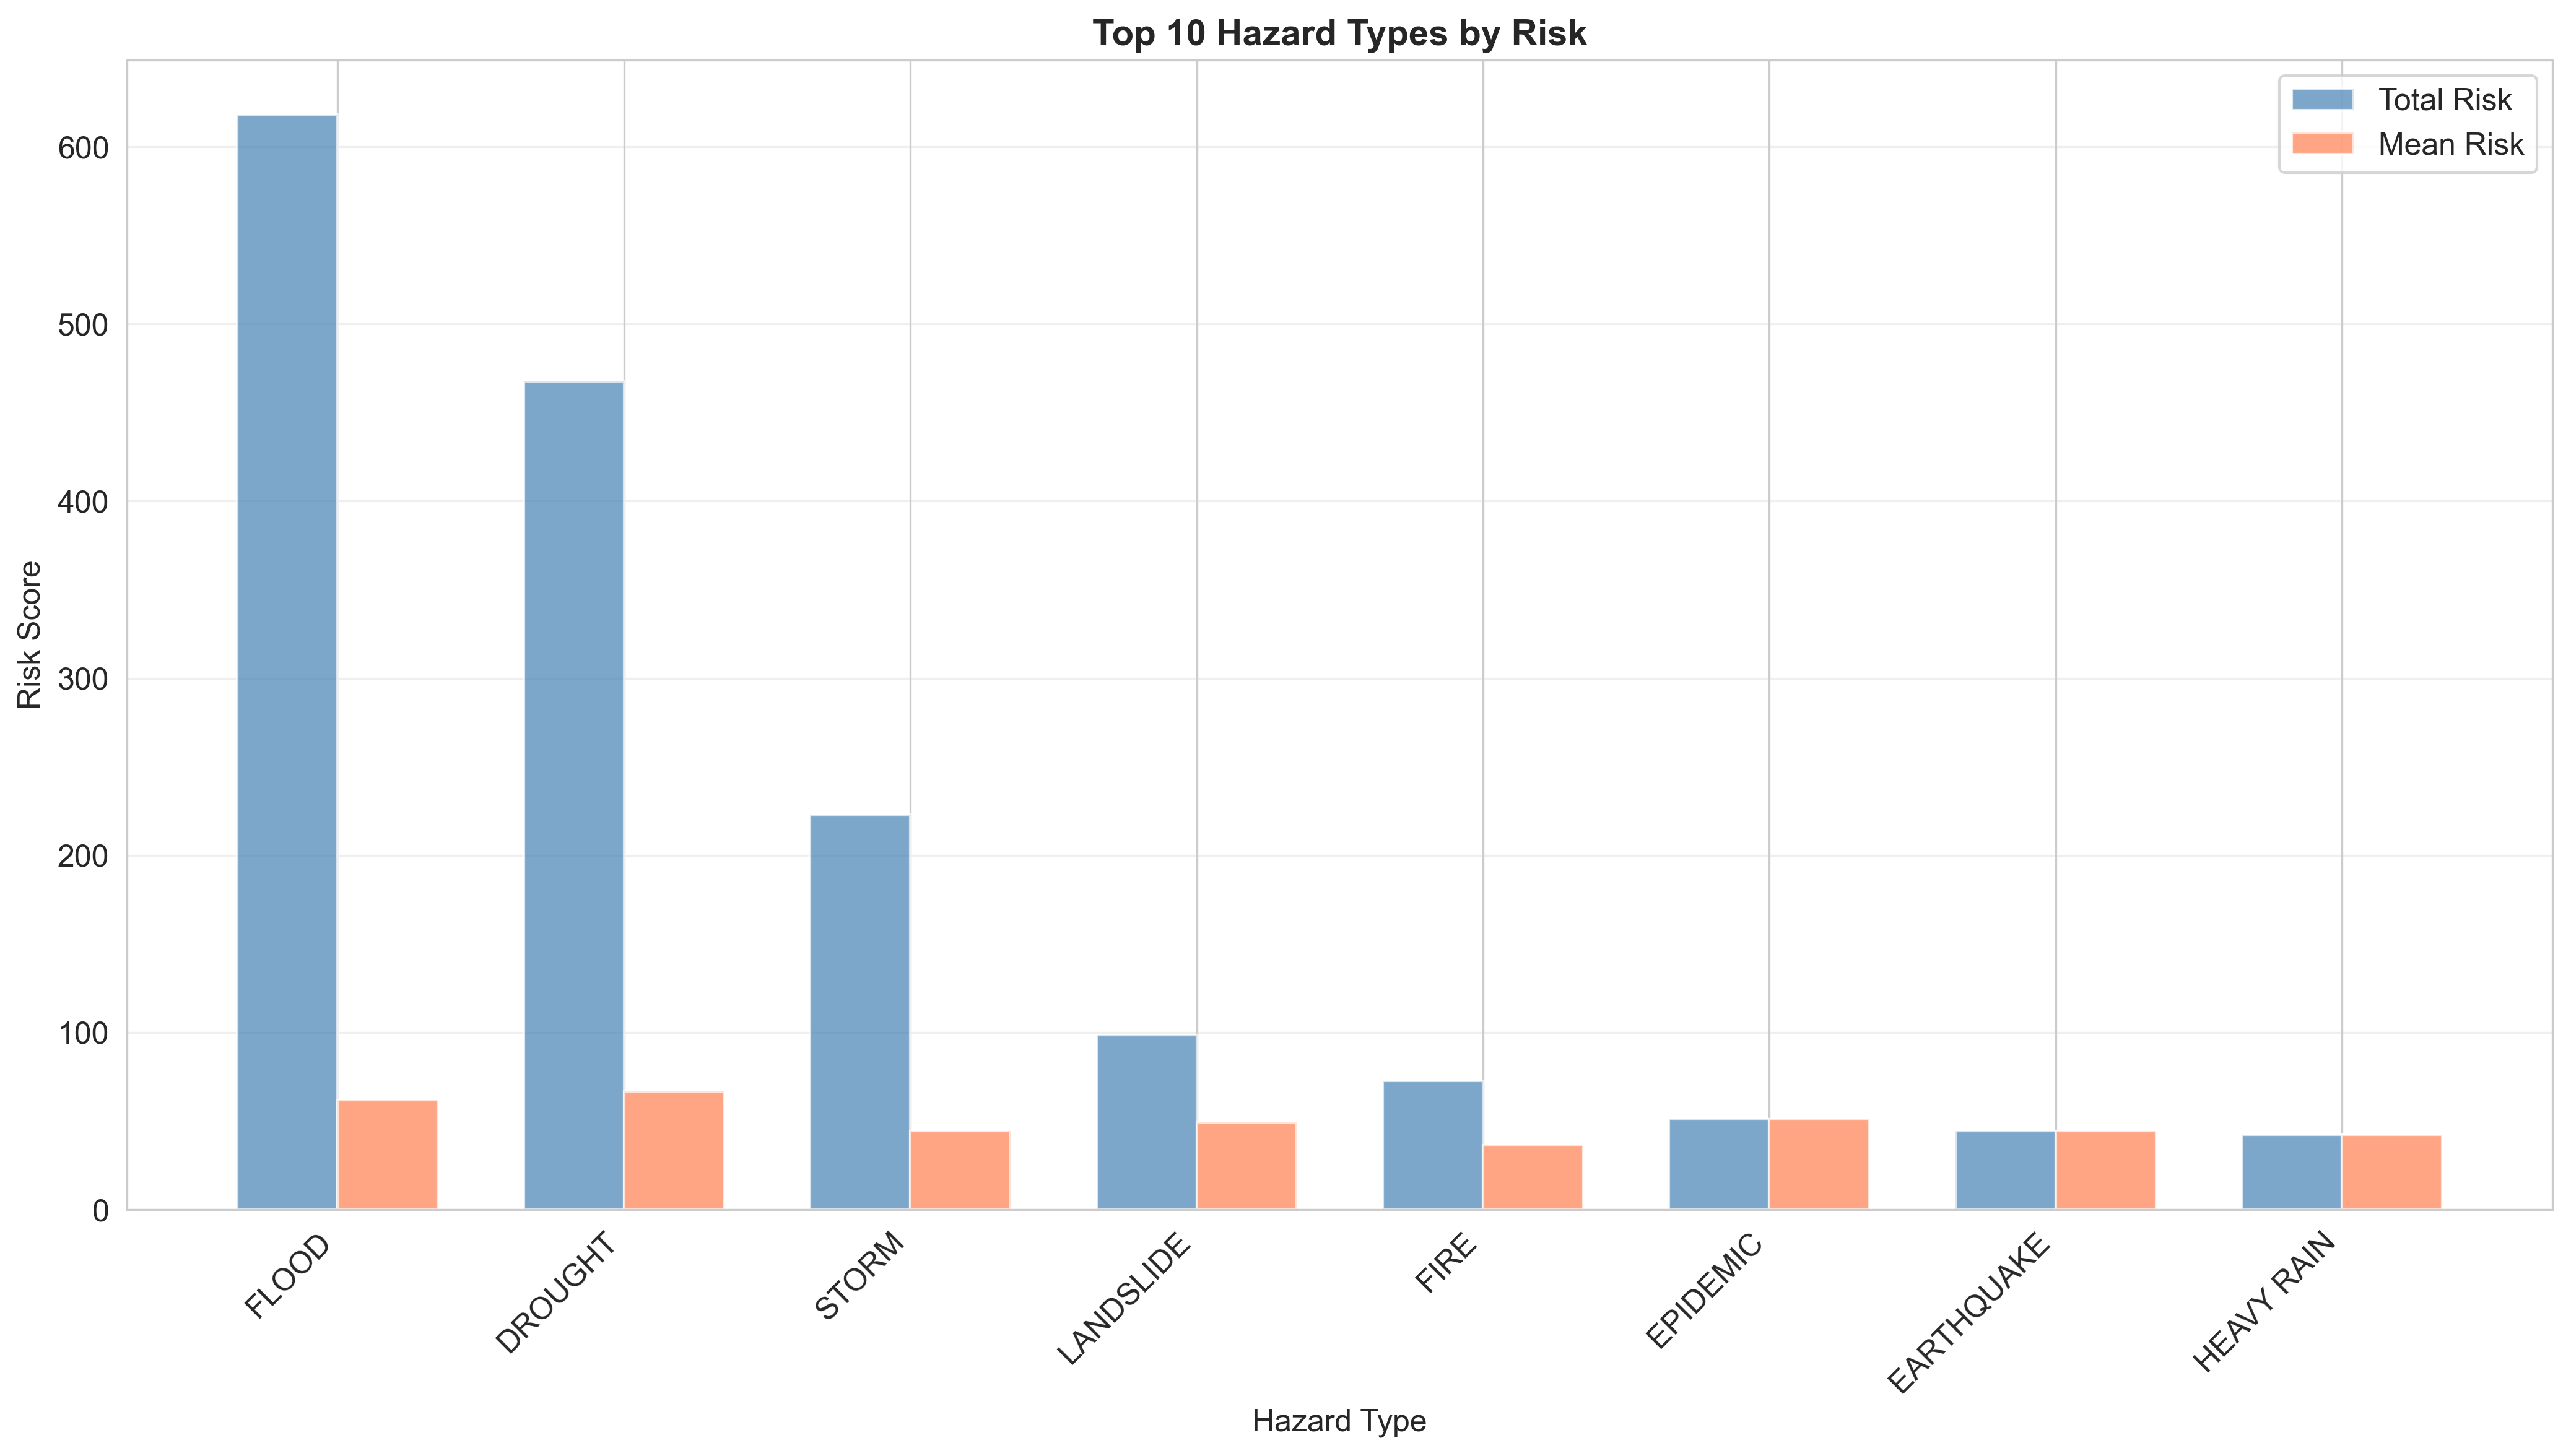

In [8]:
if df is not None:
    # Aggregate risk by hazard type
    hazard_risk = location_hazard_freq.groupby('hazard').agg({
        'risk_score_normalized': ['sum', 'mean', 'max'],
        'location': 'count',
        'event_count': 'sum'
    }).reset_index()
    
    hazard_risk.columns = ['hazard', 'total_risk', 'mean_risk', 'max_risk', 
                           'affected_locations', 'total_events']
    hazard_risk = hazard_risk.sort_values('total_risk', ascending=False)
    
    print("Risk Assessment by Hazard Type:")
    print("="*60)
    display(hazard_risk.head(15))
    
    # Visualize
    fig, ax = plt.subplots(figsize=(14, 8))
    top_hazards = hazard_risk.head(10)
    
    x = range(len(top_hazards))
    width = 0.35
    
    ax.bar([i - width/2 for i in x], top_hazards['total_risk'], 
           width, label='Total Risk', color='steelblue', alpha=0.7)
    ax.bar([i + width/2 for i in x], top_hazards['mean_risk'], 
           width, label='Mean Risk', color='coral', alpha=0.7)
    
    ax.set_xlabel('Hazard Type', fontsize=12)
    ax.set_ylabel('Risk Score', fontsize=12)
    ax.set_title('Top 10 Hazard Types by Risk', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(top_hazards['hazard'], rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '04_hazard_risk.png', dpi=300, bbox_inches='tight')
    plt.show()

## 8. Priority Areas for Intervention

In [9]:
if df is not None:
    # Identify priority areas (Very High and High risk)
    priority_areas = location_hazard_freq[
        location_hazard_freq['risk_level'].isin(['Very High', 'High'])
    ].sort_values('risk_score_normalized', ascending=False)
    
    print("🎯 PRIORITY AREAS FOR INTERVENTION:")
    print("="*80)
    print(f"\nTotal priority combinations: {len(priority_areas)}")
    print(f"  - Very High Risk: {len(priority_areas[priority_areas['risk_level'] == 'Very High'])}")
    print(f"  - High Risk: {len(priority_areas[priority_areas['risk_level'] == 'High'])}")
    
    print("\nTop 20 Priority Interventions:")
    display(priority_areas.head(20)[[
        'location', 'hazard', 'annual_frequency', 'mean_severity', 
        'risk_score_normalized', 'risk_level'
    ]])
    
    # Group by location for intervention planning
    priority_locations = priority_areas.groupby('location').agg({
        'hazard': lambda x: ', '.join(x),
        'risk_score_normalized': 'sum',
        'event_count': 'sum'
    }).reset_index()
    
    priority_locations.columns = ['location', 'priority_hazards', 'total_risk', 'total_events']
    priority_locations = priority_locations.sort_values('total_risk', ascending=False)
    
    print("\n📍 Priority Locations Summary:")
    display(priority_locations.head(10))

🎯 PRIORITY AREAS FOR INTERVENTION:

Total priority combinations: 26
  - Very High Risk: 7
  - High Risk: 19

Top 20 Priority Interventions:


,location,hazard,annual_frequency,mean_severity,risk_score_normalized,risk_level
11,Lower Shabelle,DROUGHT,0.071429,27.158081,79.396147,Very High
3,Bay,DROUGHT,0.071429,26.524476,77.543813,Very High
24,Somali,DROUGHT,0.071429,23.337245,68.226002,Very High
19,Nyanza,FLOOD,0.071429,21.778166,63.668064,Very High
2,Banadir,DROUGHT,0.071429,21.596494,63.136950,Very High
27,Western,FLOOD,0.071429,21.312635,62.307094,Very High
17,North Eastern,DROUGHT,0.071429,20.869998,61.013052,Very High
7,Eastern,DROUGHT,0.071429,20.493422,59.912139,High
12,Morogoro,FLOOD,0.071429,20.455565,59.801466,High
22,Rift Valley,FLOOD,0.071429,20.045677,58.603166,High



📍 Priority Locations Summary:


,location,priority_hazards,total_risk,total_events
7,Eastern,"DROUGHT, FLOOD",113.300988,2
17,Rift Valley,"FLOOD, EPIDEMIC",109.822749,2
22,Western,"FLOOD, LANDSLIDE",108.851679,2
9,Lower Shabelle,DROUGHT,79.396147,1
3,Bay,DROUGHT,77.543813,1
19,Somali,DROUGHT,68.226002,1
15,Nyanza,FLOOD,63.668064,1
2,Banadir,DROUGHT,63.136950,1
13,North Eastern,DROUGHT,61.013052,1
10,Morogoro,FLOOD,59.801466,1


## 9. Risk Trends Over Time

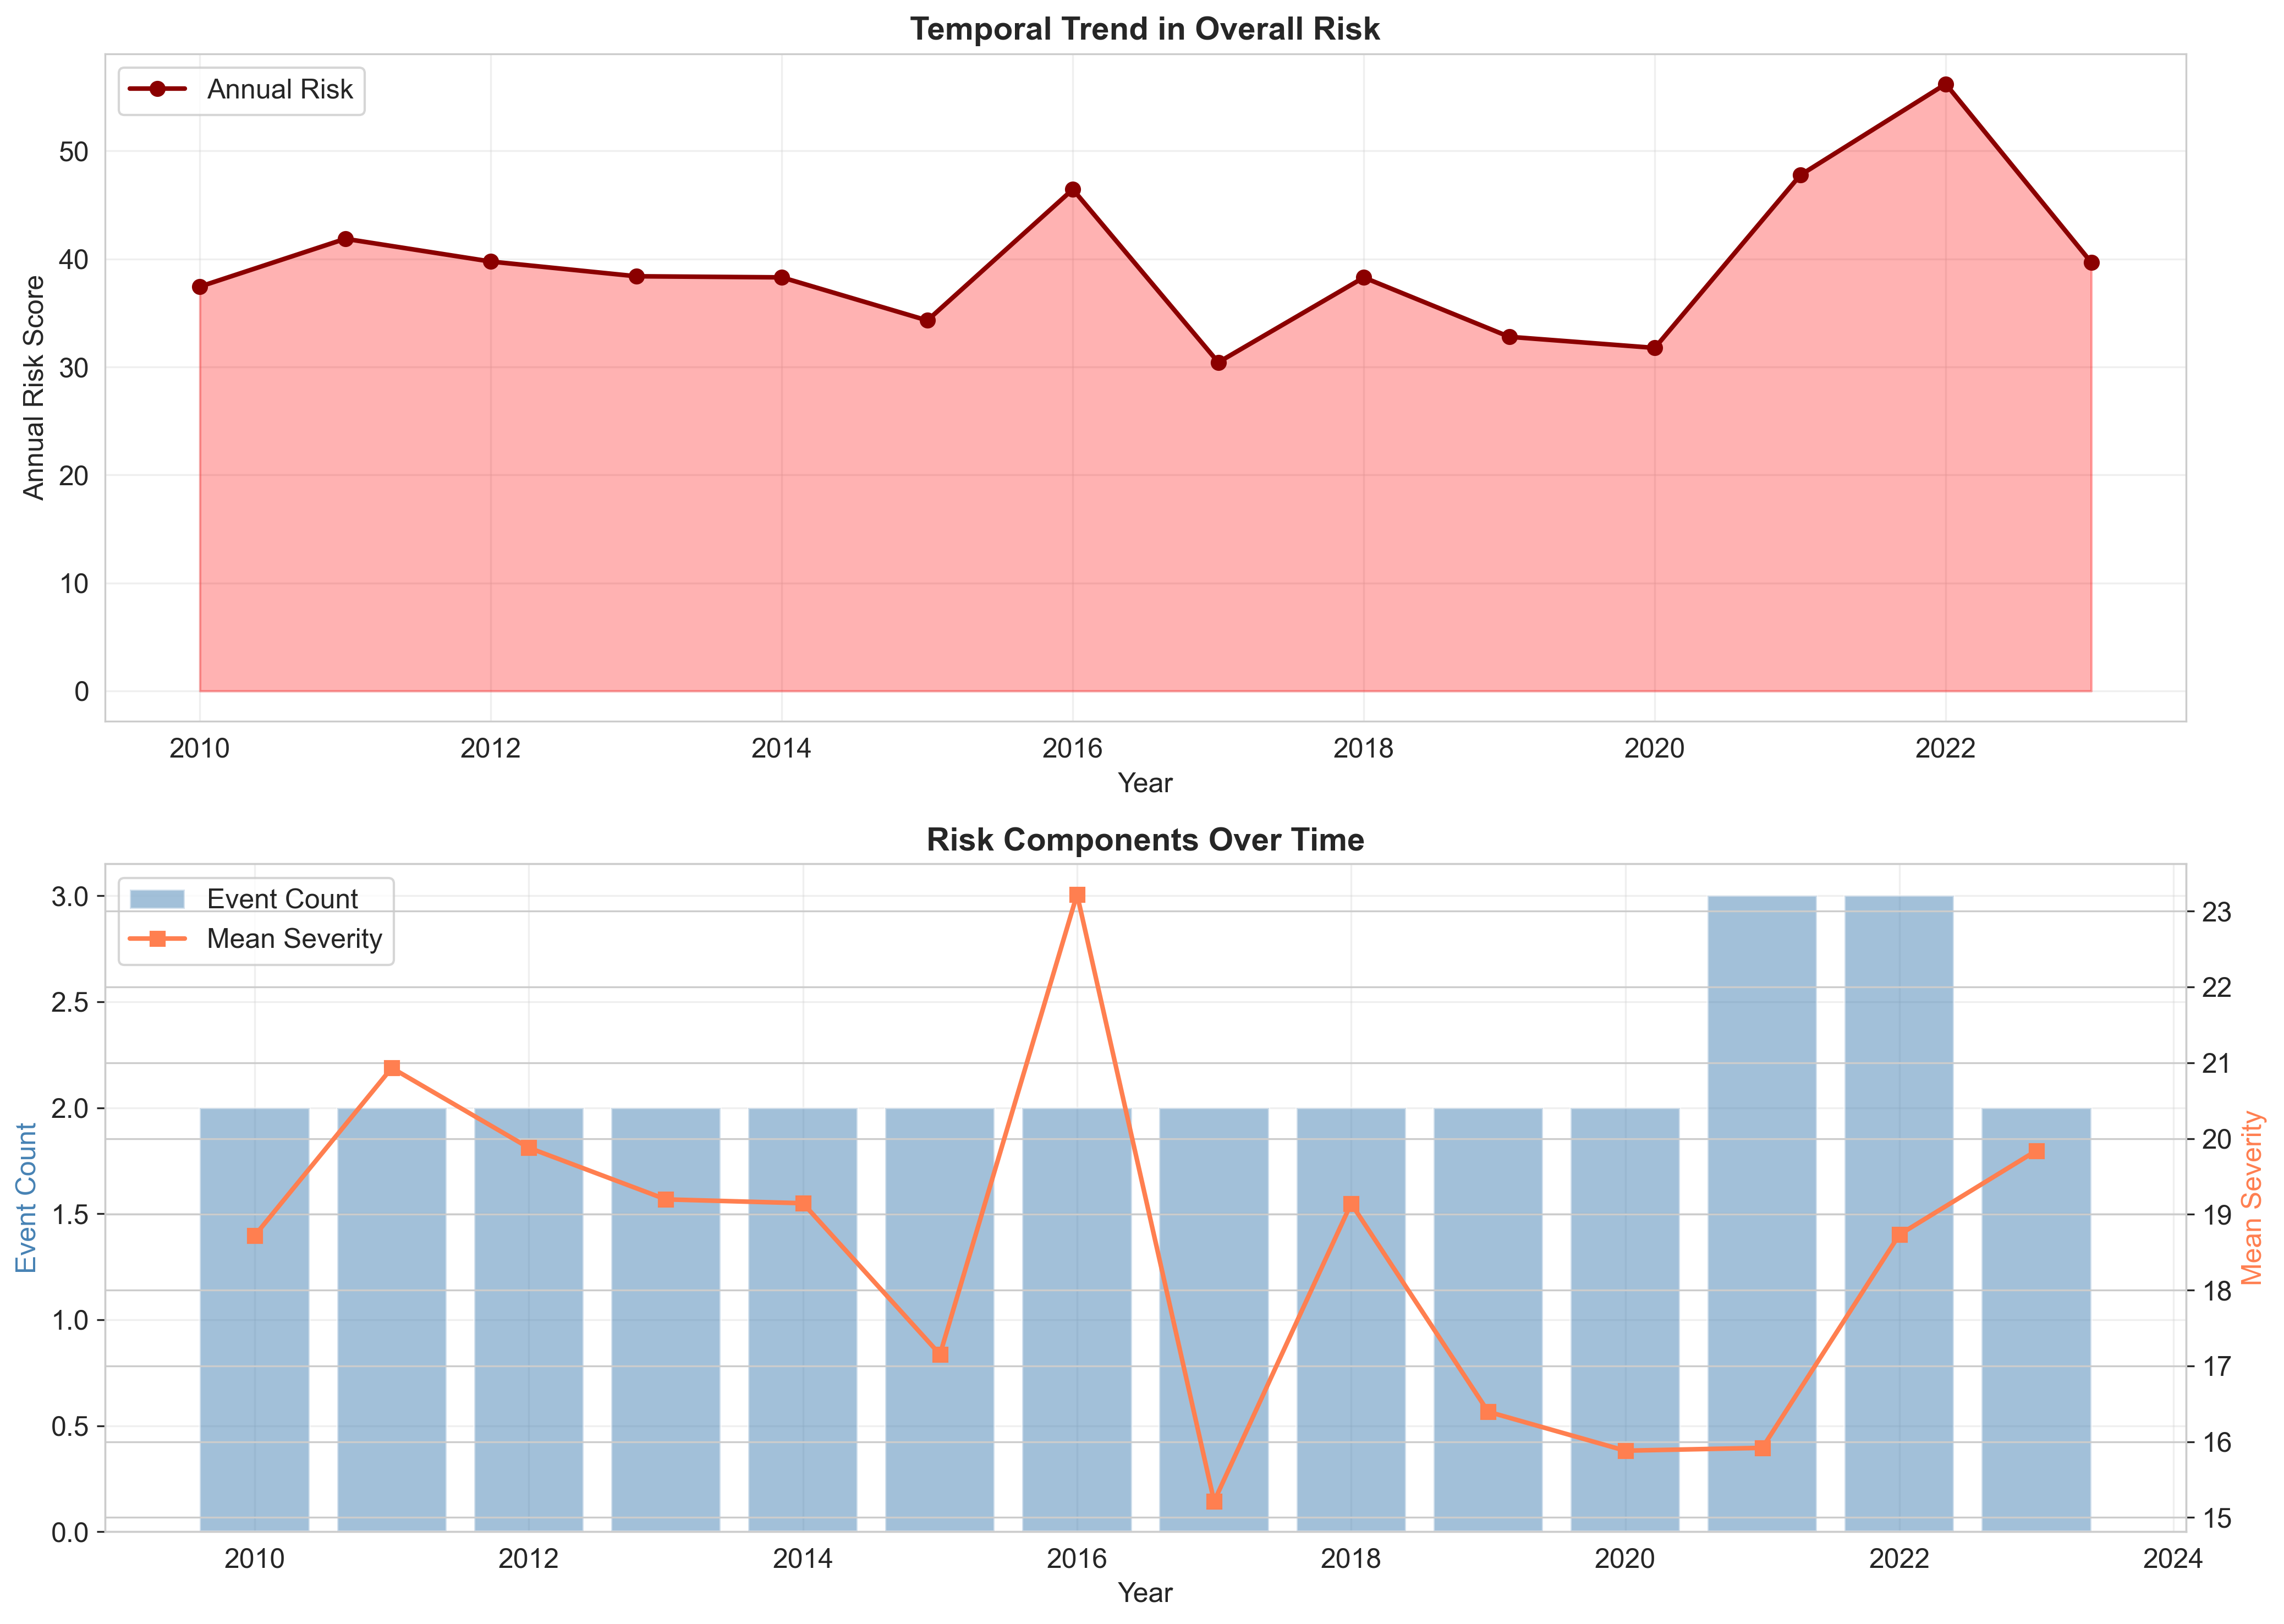

In [10]:
if df is not None and 'year' in df.columns:
    # Calculate annual risk metrics
    yearly_risk = df.groupby('year').agg({
        'severity_index': 'mean',
        'serial': 'count'  # Count events using serial column instead of year
    }).reset_index()
    
    yearly_risk.columns = ['year', 'mean_severity', 'event_count']
    yearly_risk['annual_risk'] = yearly_risk['event_count'] * yearly_risk['mean_severity']
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # Annual risk trend
    ax1.plot(yearly_risk['year'], yearly_risk['annual_risk'], 
             marker='o', linewidth=2, color='darkred', label='Annual Risk')
    ax1.fill_between(yearly_risk['year'], yearly_risk['annual_risk'], 
                      alpha=0.3, color='red')
    ax1.set_xlabel('Year', fontsize=12)
    ax1.set_ylabel('Annual Risk Score', fontsize=12)
    ax1.set_title('Temporal Trend in Overall Risk', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Components: frequency and severity
    ax2_twin = ax2.twinx()
    
    ax2.bar(yearly_risk['year'], yearly_risk['event_count'], 
            alpha=0.5, color='steelblue', label='Event Count')
    ax2_twin.plot(yearly_risk['year'], yearly_risk['mean_severity'], 
                  marker='s', linewidth=2, color='coral', label='Mean Severity')
    
    ax2.set_xlabel('Year', fontsize=12)
    ax2.set_ylabel('Event Count', fontsize=12, color='steelblue')
    ax2_twin.set_ylabel('Mean Severity', fontsize=12, color='coral')
    ax2.set_title('Risk Components Over Time', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # Combine legends
    lines1, labels1 = ax2.get_legend_handles_labels()
    lines2, labels2 = ax2_twin.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '04_risk_temporal_trends.png', dpi=300, bbox_inches='tight')
    plt.show()

## 10. Summary and Recommendations

In [11]:
if df is not None:
    print("="*80)
    print("COMPREHENSIVE RISK ASSESSMENT SUMMARY")
    print("="*80)
    
    print("\n📊 Overall Risk Profile:")
    print(f"   - Total location-hazard combinations analyzed: {len(location_hazard_freq)}")
    print(f"   - Very High Risk combinations: {len(location_hazard_freq[location_hazard_freq['risk_level'] == 'Very High'])}")
    print(f"   - High Risk combinations: {len(location_hazard_freq[location_hazard_freq['risk_level'] == 'High'])}")
    
    print("\n🎯 Priority Interventions Needed:")
    print(f"   - {len(priority_locations)} locations require priority attention")
    print(f"   - Top 3 highest risk locations:")
    for i, row in priority_locations.head(3).iterrows():
        print(f"     {i+1}. {row['location']} (Risk Score: {row['total_risk']:.1f})")
    
    print("\n⚠️  Highest Risk Hazard Types:")
    for i, row in hazard_risk.head(3).iterrows():
        print(f"   {i+1}. {row['hazard']} (Total Risk: {row['total_risk']:.1f})")
    
    print("\n📈 Key Recommendations:")
    print("   1. Prioritize resources for Very High and High risk areas")
    print("   2. Develop hazard-specific mitigation strategies")
    print("   3. Strengthen early warning systems in high-risk locations")
    print("   4. Invest in resilience building for multi-hazard exposed areas")
    print("   5. Establish monitoring systems for emerging risk trends")
    
    print("\n📋 Next Steps:")
    print("   1. Proceed to case studies (notebook 05) for detailed analysis")
    print("   2. Develop specific recommendations (notebook 06)")
    print("   3. Generate policy brief with actionable insights")

COMPREHENSIVE RISK ASSESSMENT SUMMARY

📊 Overall Risk Profile:
   - Total location-hazard combinations analyzed: 29
   - Very High Risk combinations: 7
   - High Risk combinations: 19

🎯 Priority Interventions Needed:
   - 23 locations require priority attention
   - Top 3 highest risk locations:
     8. Eastern (Risk Score: 113.3)
     18. Rift Valley (Risk Score: 109.8)
     23. Western (Risk Score: 108.9)

⚠️  Highest Risk Hazard Types:
   5. FLOOD (Total Risk: 618.0)
   1. DROUGHT (Total Risk: 467.7)
   8. STORM (Total Risk: 223.0)

📈 Key Recommendations:
   1. Prioritize resources for Very High and High risk areas
   2. Develop hazard-specific mitigation strategies
   3. Strengthen early warning systems in high-risk locations
   4. Invest in resilience building for multi-hazard exposed areas
   5. Establish monitoring systems for emerging risk trends

📋 Next Steps:
   1. Proceed to case studies (notebook 05) for detailed analysis
   2. Develop specific recommendations (notebook 06

## 11. Save Risk Assessment Results

In [12]:
if df is not None:
    # Save detailed risk assessment
    risk_file = PROCESSED_DATA_DIR / 'risk_assessment_detailed.csv'
    location_hazard_freq.to_csv(risk_file, index=False)
    print(f"✅ Detailed risk assessment saved to: {risk_file}")
    
    # Save location summary
    location_file = PROCESSED_DATA_DIR / 'risk_assessment_by_location.csv'
    location_risk.to_csv(location_file, index=False)
    print(f"✅ Location risk summary saved to: {location_file}")
    
    # Save priority areas
    priority_file = PROCESSED_DATA_DIR / 'priority_interventions.csv'
    priority_areas.to_csv(priority_file, index=False)
    print(f"✅ Priority interventions saved to: {priority_file}")
    
    print("\n✅ Risk assessment complete! Ready for case studies and recommendations.")

✅ Detailed risk assessment saved to: D:\Projects\sendai-multi-hazard-risk-modeling\data\processed\risk_assessment_detailed.csv
✅ Location risk summary saved to: D:\Projects\sendai-multi-hazard-risk-modeling\data\processed\risk_assessment_by_location.csv
✅ Priority interventions saved to: D:\Projects\sendai-multi-hazard-risk-modeling\data\processed\priority_interventions.csv

✅ Risk assessment complete! Ready for case studies and recommendations.
